In [2]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
print("Libraries loaded!")

Libraries loaded!


In [3]:
#load dataset
df = sns.load_dataset("titanic")
print(df.shape) #how many rows and columns
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
#basic info
df.info()
#column names, data types, how many non-null values

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [6]:
# summary statistics
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


age            177
embarked         2
deck           688
embark_town      2
dtype: int64


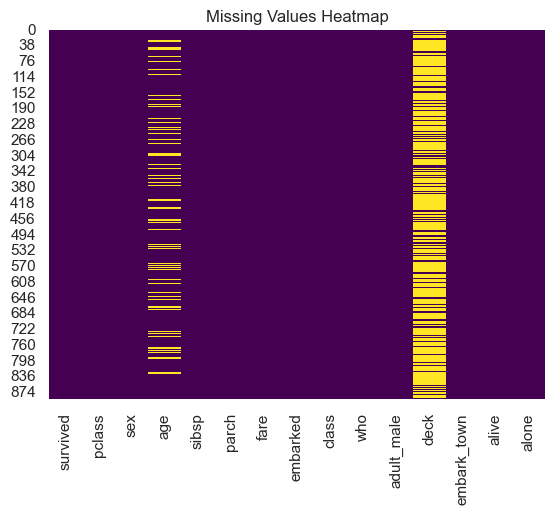

In [8]:
#Missing values
missing = df.isnull().sum()
print(missing[missing > 0]) #only show columns with missing values

#Visualize missing values
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()
#yellow = missing, purple = non-missing

survived
0    549
1    342
Name: count, dtype: int64


C:\Users\Srivani\AppData\Local\Temp\ipykernel_26340\481750015.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="survived", data=df, palette='Set2')


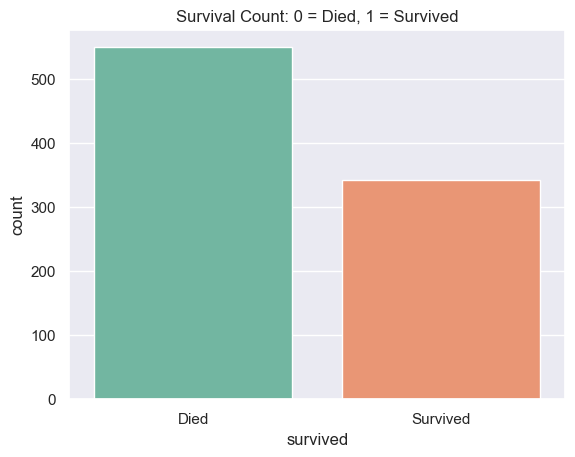

In [11]:
#Survival count
print(df["survived"].value_counts())
#0 = did not survive, 1 = survived
sns.countplot(x="survived", data=df, palette='Set2')
plt.title("Survival Count: 0 = Died, 1 = Survived")
plt.xticks([0, 1], ["Died", "Survived"]) #replaces x-axis labels
plt.show()

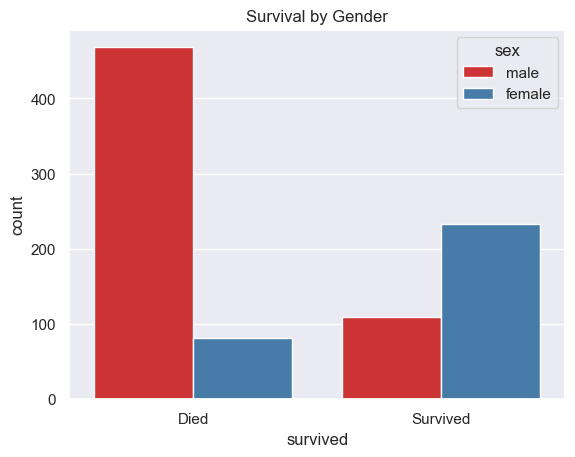

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64


In [12]:
#Survival by Gender
sns.countplot(x='survived', hue='sex', data=df, palette='Set1')
plt.title("Survival by Gender")
plt.xticks([0, 1], ["Died", "Survived"])
plt.show()

print(df.groupby('sex')['survived'].mean()) #proportion of survivors

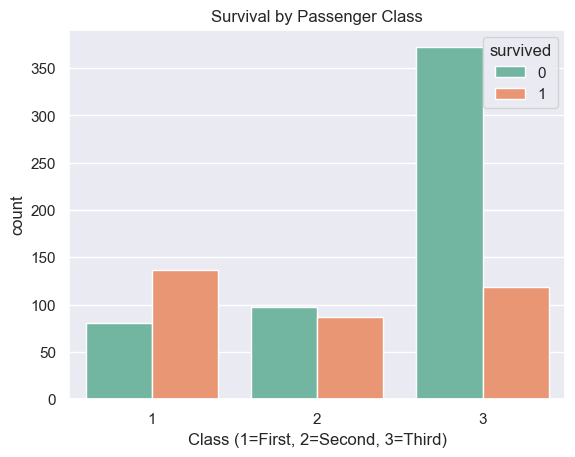

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


In [13]:
#Survival by Passenger Class
sns.countplot(x='pclass', hue='survived', data=df, palette='Set2')
plt.title("Survival by Passenger Class")
plt.xlabel("Class (1=First, 2=Second, 3=Third)")
plt.show()

print(df.groupby('pclass')['survived'].mean()) #proportion of survivors by class

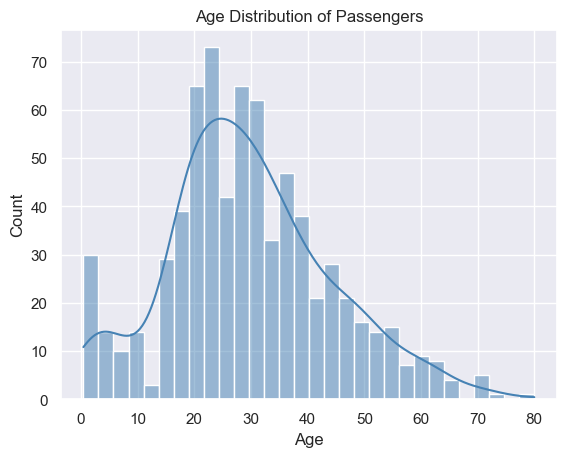

Average age: 29.7
Oldest: 80.0
Youngest: 0.42


In [14]:
#Age distribution
sns.histplot(df['age'].dropna(), bins=30, kde=True, color='steelblue')
#dropna() removes missing values for age
#bins divides the age range into 30 bars. more bins = more detail, fewer bins = more general    
#kde=True adds a smooth curve to show the distribution shape and color sets the bar color
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.show()

print(f"Average age: {df['age'].mean():.1f}")
print(f"Oldest: {df['age'].max()}")
print(f"Youngest: {df['age'].min()}")

C:\Users\Srivani\AppData\Local\Temp\ipykernel_26340\750967915.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='survived', y='age', data=df, palette='Set3')


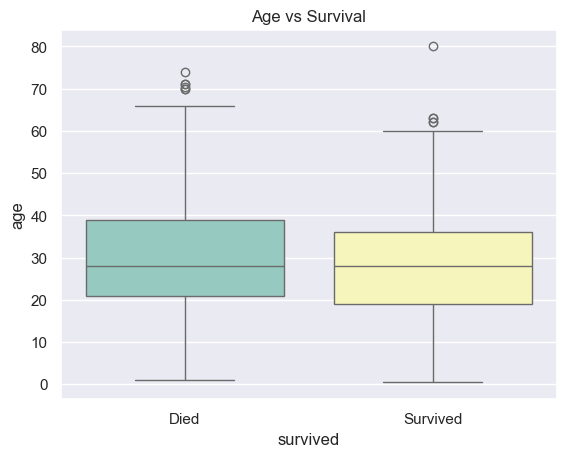

In [15]:
#Age vs Survival
sns.boxplot(x='survived', y='age', data=df, palette='Set3')
plt.title("Age vs Survival")
plt.xticks([0, 1], ["Died", "Survived"])
plt.show()

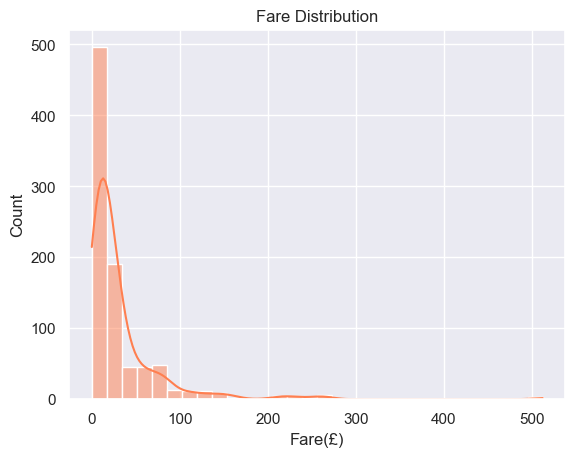

Average fare: £32.20
Most expensive ticket: £512.33


In [16]:
#Fare distribution
sns.histplot(df['fare'], bins=30, kde=True, color='coral')
plt.title("Fare Distribution")
plt.xlabel("Fare(£)")
plt.show()  

print(f"Average fare: £{df['fare'].mean():.2f}")
print(f"Most expensive ticket: £{df['fare'].max():.2f}")

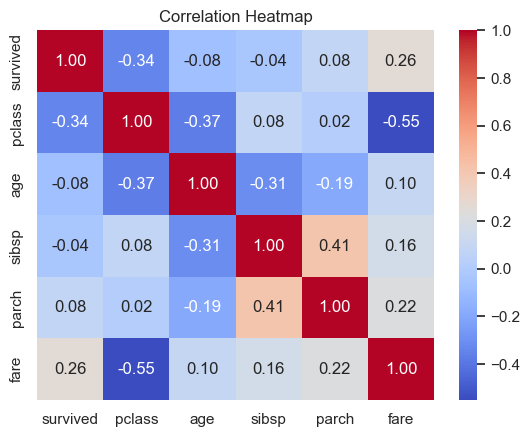

In [17]:
#Correlation heatmap
#only include numeric columns for correlation
numeric_df = df[['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']]

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()
#annot=True shows the numbers inside each box
#Red = positive correlation, Blue = negative correlation, White = no correlation

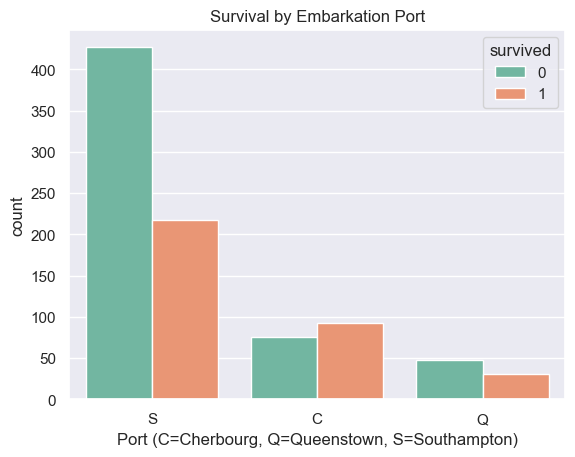

In [18]:
#Survival by Embarkation Port
sns.countplot(x='embarked', hue='survived', data=df, palette='Set2')
plt.title("Survival by Embarkation Port")
plt.xlabel("Port (C=Cherbourg, Q=Queenstown, S=Southampton)")
plt.show()

In [19]:
#Key Findings
print("""
KEY FINDINGS FROM TITANIC EDA
------------------------------
1.Only about 38% of passengers survived.
2.Women had a much higher survival rate than men (74% vs 19%).
3.First class passengers had a much higher survival rate (63%) than second (47%) and third class (24%).
4.Childrean(younger passengers) had slightly higher survival rates than adults.
5.Higher fare correlates with higher survival (links to class)
6.About 117 age values are missing - needs handling before modeling
7.Most passengers embarked from Southampton, which had the lowest survival rate.""")




KEY FINDINGS FROM TITANIC EDA
------------------------------
1.Only about 38% of passengers survived.
2.Women had a much higher survival rate than men (74% vs 19%).
3.First class passengers had a much higher survival rate (63%) than second (47%) and third class (24%).
4.Childrean(younger passengers) had slightly higher survival rates than adults.
5.Higher fare correlates with higher survival (links to class)
6.About 117 age values are missing - needs handling before modeling
7.Most passengers embarked from Southampton, which had the lowest survival rate.
